## 3DoF Quadrotor SCP

Imports

In [ ]:
# Basic imports
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp as scp
import trajopt.core.problem as prob
import trajopt.utils.config_loader as cfg
import trajopt.utils.tools as tools
import trajopt.analysis.default_analysis as default_analysis
import trajopt.analysis.statistics as stats
import copy

setup problem and run SCP

In [ ]:
from typing import Any

def add_monte_carlo_dispersions(mission_dict, realization):
    for mc_var, mc_disp in realization.items():
        mission_dict[mc_var] = mission_dict[mc_var] + mc_disp

gen_mc_variations    = 1
save_mc_variations   = 1
save_scenario_data   = 1

example_name = "quadrotor_3dof"
mc_name = "mc1"
scenario_data_name = example_name

nominal_config  = cfg.load_configs(example_name)

mv_variations = cfg.load_mv_variations(example_name)

if gen_mc_variations:
    mc_variations = cfg.gen_mc_variations(example_name)

    if save_mc_variations:
        np.save(f"data/mc_variations/{mc_name}", mc_variations)
else:
    mc_variations = np.load(f"data/mc_variations/{mc_name}.npy", allow_pickle=True).item()

variations = {
    "method": mv_variations,
    "mission": mc_variations
}

scenario_data = {}

# loop through method variations
for name, method_variation in variations["method"].items():
    
    # initialize method sub-dictionary for scenario_data dict
    scenario_data[name] = {"method_params": {},
                                  'mc_data': [None] * (variations["mission"]["num_variations"] + 1),
                                  }

    cached_subprob = None
    
    # loop through monte-carlo mission parameter realizations (number of runs)
    for run_idx, realization in enumerate(variations["mission"]["realizations"]):
        
        # take in nominal configs
        run_config = copy.deepcopy(nominal_config)

        # set method variations
        run_config["method"] = tools.deep_update(run_config["method"], method_variation)

        # set monte carlo mission variations
        add_monte_carlo_dispersions(run_config["mission"], realization)

        # create problem instance
        problem = prob.Problem(run_config, cached_subprob)
        
        # run SCP
        problem = scp.run_scp(problem)

        # perform default analysis on this mc run and store related params
        scenario_data[name]["mc_data"][run_idx] = default_analysis.perform_default_analysis(problem)

        # store total time for scp (used to calculate time to converge)
        scenario_data[name]['mc_data'][run_idx] = problem.solution['t_all']
        
        # cache subproblem graph to speed up solves
        cached_subprob = None # problem.method.subprob

if save_scenario_data:
    np.save(f"data/scenario_data/{scenario_data_name}_{mc_name}", scenario_data)

scales: 
d: 10.0000, t: 1.0000, m: 1.0000, v: 10.0000, a: 10.0000, f: 10.0000, ang: 57.2958, angv: 57.2958
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: quadrotor: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------------------------------------------------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    00068.2   |   0005.9  |   0000.0   |   -0.3    |      -01.2      |    -03.1    |     -12.0   |    optimal    |   12.00   |  541.3
     02     |    00056.2   |   0005.7  |   0000.0   |   -0.9    |      -02.0      |    -04.4    |     -12.0   |    optimal    |   12.69   |  480.2
     03     |    00075.5   |   0006.2  |   0000.0   |   -1.3    |      -02.0      |    -04.6    |     -12.0   |    optimal    |   14.41   |  476.7
     04     |    00072.0   |   0010.5  |   0000.0   |   -1.4    |      -02.1      |    -04.8    |     -12.0   |    optimal    |   16.21   |  474.7
     05     |    00061.1   |   0004.8  |   0000.0   |   -1.6    |      -02.3      |    -04.9    |     -12.0   |    optimal    |   17.87   |  473.7
     06     |    00040.4   |   0009.7  |   0000.0   |   -1.7    |      -02.6      |    -05.0    |     -12.0   |    optimal    |   19.40   |  473.0
     07     |    00056.7   |   0027.4  |   0000.0   |   -2.0    |      -02.8      |    -05.0    |     -12.0   |    opt

run statistical analysis

In [ ]:
# file path if you wish to save LaTeX tables (eg. path to a data/statistics/mc1_stats.txt)
file = None # example: ~/acl-link/prototypes/trajopt/src/trajopt/examples/quadrotor_3dof/data/stats/mc1_stats.txt

# generate and print statistics and associated tables
analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

make plots

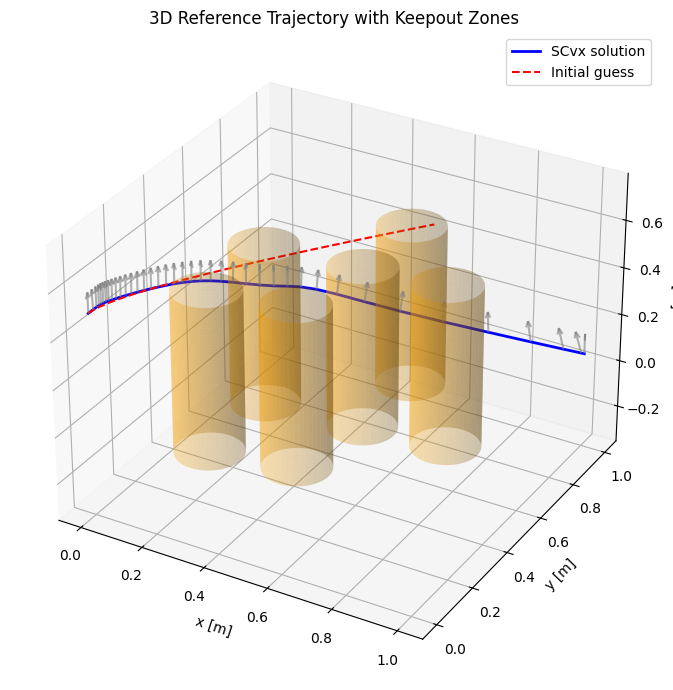

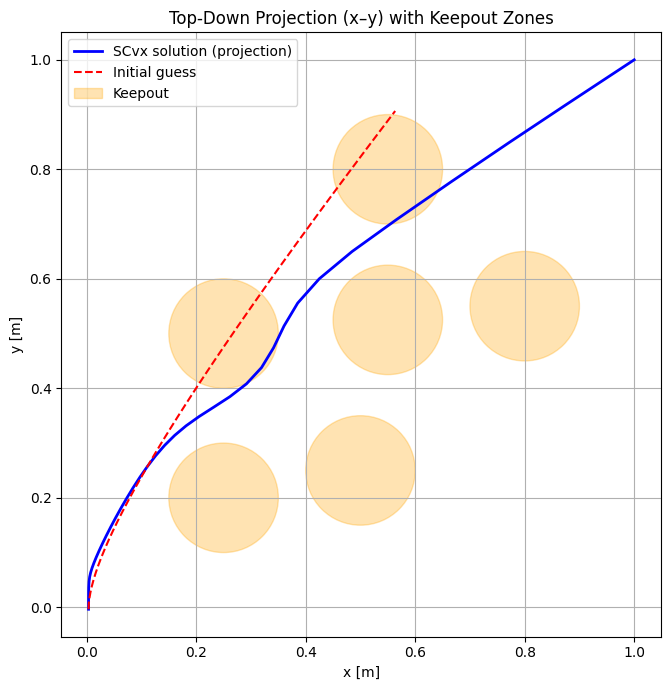

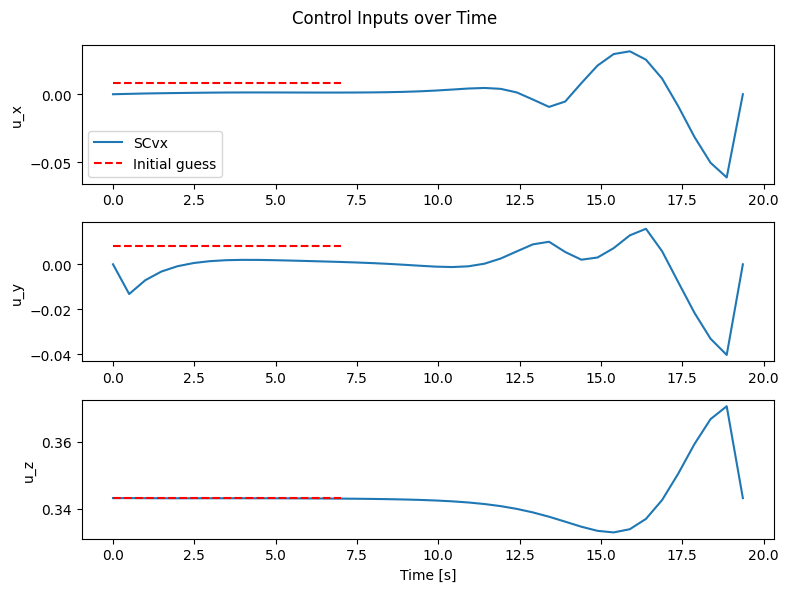

In [3]:
# --- 3D Interactivity (run %matplotlib widget in Jupyter) ---
# run this once per notebook session
#%matplotlib widget

mission = problem.mission
model   = problem.model
method  = problem.method

# --- Retrieve trajectory and parameters ---

ts_init = method.ts_init
zs_init = method.zs_init
us_init = method.us_init
x_init  = zs_init[:, 0]
y_init  = zs_init[:, 1]
z_init  = zs_init[:, 2]

ts_opt  = problem.solution["ts"]
zs_opt  = problem.solution["zs"]
us_opt  = problem.solution["us"]

# ============================================================
# 3D Trajectory Plot
# ============================================================
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# --- Trajectories ---
ax.plot(zs_opt[:, 0], zs_opt[:, 1], zs_opt[:, 2],
        'b-', linewidth=2, label="SCvx solution")
ax.plot(x_init, y_init, z_init,
        'r--', linewidth=1.5, label="Initial guess")

# --- Thrust vectors (downsampled for clarity) ---
us_opt_scaled = 0.25 * us_opt
skip = max(1, len(zs_opt) // 25)
ax.quiver(
    zs_opt[::skip, 0], zs_opt[::skip, 1], zs_opt[::skip, 2],
    us_opt_scaled[::skip, 0], us_opt_scaled[::skip, 1], us_opt_scaled[::skip, 2],
    length=1.0, normalize=False, color='gray', alpha=0.6
)

# ============================================================
# Cylindrical Keepout Zones
# ============================================================
n_nfz = mission.n_nfz
z_traj_max = np.max(zs_opt[:, 2])
z_traj_min = np.min(zs_opt[:, 2])
height = (z_traj_max - z_traj_min) * 1.5  # cylinders taller than trajectory
z_bottom = z_traj_min - 0.25 * height
z_top = z_bottom + height

for i in range(n_nfz):
    xc = mission.obs['xc'][i]
    yc = mission.obs['yc'][i]
    rc = mission.obs['rc'][i]

    s = np.linspace(0, 2 * np.pi, 100)
    z = np.linspace(z_bottom, z_top, 50)
    S, Z = np.meshgrid(s, z)
    X = xc + rc * np.cos(S)
    Y = yc + rc * np.sin(S)
    ax.plot_surface(X, Y, Z, color='orange', alpha=0.3, linewidth=0, shade=True)

# ============================================================
# Equal Axis Scaling
# ============================================================
def set_axes_equal(ax):
    """Make 3D axes have equal scale."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    max_range = max([x_range, y_range, z_range]) / 2.0
    mid_x = np.mean(x_limits)
    mid_y = np.mean(y_limits)
    mid_z = np.mean(z_limits)
    ax.set_xlim3d([mid_x - max_range, mid_x + max_range])
    ax.set_ylim3d([mid_y - max_range, mid_y + max_range])
    ax.set_zlim3d([mid_z - max_range, mid_z + max_range])

set_axes_equal(ax)

# --- Labels, Legend ---
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("3D Reference Trajectory with Keepout Zones")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Top-Down Projection (x–y plane)
# ============================================================
fig, ax2d = plt.subplots(figsize=(7, 7))

# Plot trajectory footprints
ax2d.plot(zs_opt[:, 0], zs_opt[:, 1], 'b-', linewidth=2, label="SCvx solution (projection)")
ax2d.plot(x_init, y_init, 'r--', linewidth=1.5, label="Initial guess")

# Plot circular obstacle projections
for i in range(n_nfz):
    xc = mission.obs['xc'][i]
    yc = mission.obs['yc'][i]
    rc = mission.obs['rc'][i]
    circle = plt.Circle((xc, yc), rc, color='orange', alpha=0.3, label="Keepout" if i == 0 else None)
    ax2d.add_patch(circle)

ax2d.set_aspect('equal', adjustable='box')
ax2d.set_xlabel("x [m]")
ax2d.set_ylabel("y [m]")
ax2d.set_title("Top-Down Projection (x–y) with Keepout Zones")
ax2d.grid(True)
ax2d.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 2D Control vs Time Plot
# ============================================================
fig = plt.figure(figsize=(8, 6))
ax_1 = fig.add_subplot(311)
ax_2 = fig.add_subplot(312)
ax_3 = fig.add_subplot(313)

ax_1.plot(ts_opt, us_opt[:, 0], label="SCvx")
ax_1.plot(ts_init, us_init[:, 0], 'r--', label="Initial guess")
ax_1.set_ylabel("u_x")

ax_2.plot(ts_opt, us_opt[:, 1])
ax_2.plot(ts_init, us_init[:, 1], 'r--')
ax_2.set_ylabel("u_y")

ax_3.plot(ts_opt, us_opt[:, 2])
ax_3.plot(ts_init, us_init[:, 2], 'r--')
ax_3.set_ylabel("u_z")
ax_3.set_xlabel("Time [s]")

ax_1.legend()
plt.suptitle("Control Inputs over Time")
plt.tight_layout()
plt.show()